Mounted at /content/drive


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MNASNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=MNASNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mnasnet1.0_top1_73.512-f206786ef8.pth" to /root/.cache/torch/hub/checkpoints/mnasnet1.0_top1_73.512-f206786ef8.pth
100%|██████████| 16.9M/16.9M [00:00<00:00, 113MB/s]



Initial Model Summary (Frozen Backbone):
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              ReLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              ReLU-6         [-1, 32, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             512
       BatchNorm2d-8         [-1, 16, 112, 112]              32
            Conv2d-9         [-1, 48, 112, 112]             768
      BatchNorm2d-10         [-1, 48, 112, 112]              96
             ReLU-11         [-1, 48, 112, 112]               0
           Conv2d-12           [-1, 48, 56, 56]             432
      BatchNorm2d-13           [-1, 48, 56, 56]              

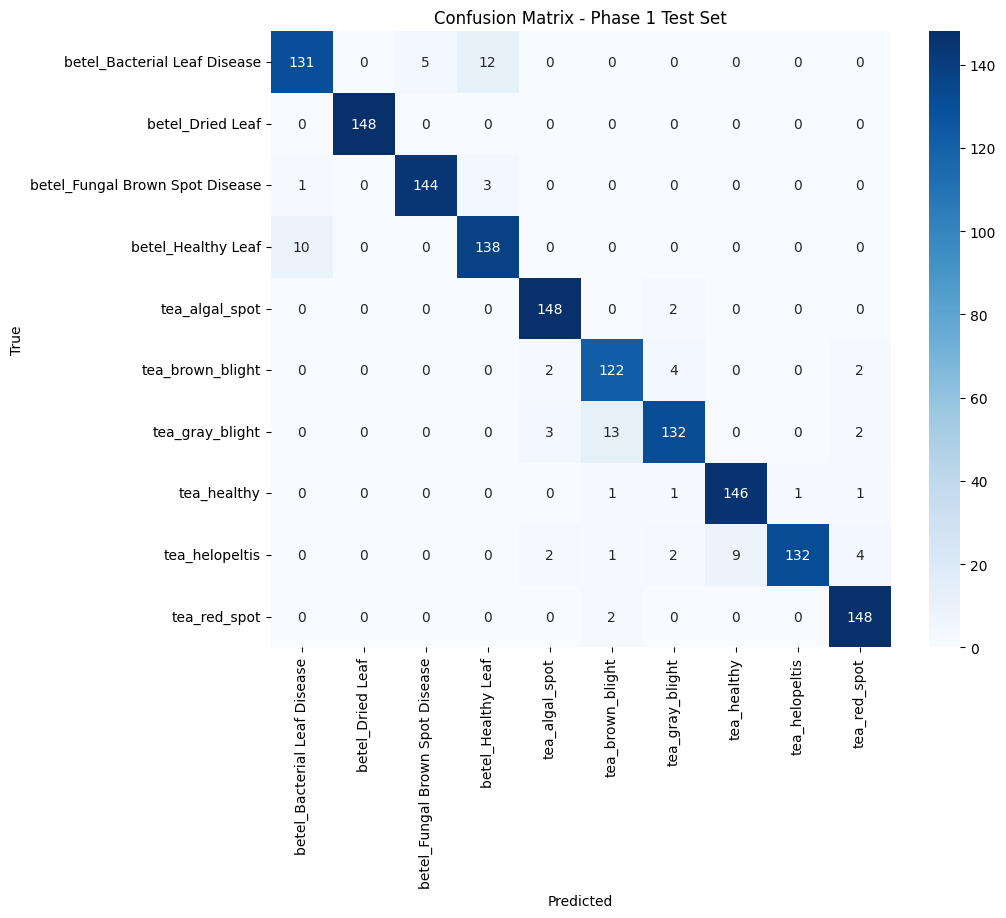


Unfreezing last 20 layers of backbone

Model Summary After Unfreezing:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              ReLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              ReLU-6         [-1, 32, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             512
       BatchNorm2d-8         [-1, 16, 112, 112]              32
            Conv2d-9         [-1, 48, 112, 112]             768
      BatchNorm2d-10         [-1, 48, 112, 112]              96
             ReLU-11         [-1, 48, 112, 112]               0
           Conv2d-12           [-1, 48, 56, 56]             432
      BatchNorm2d-13           

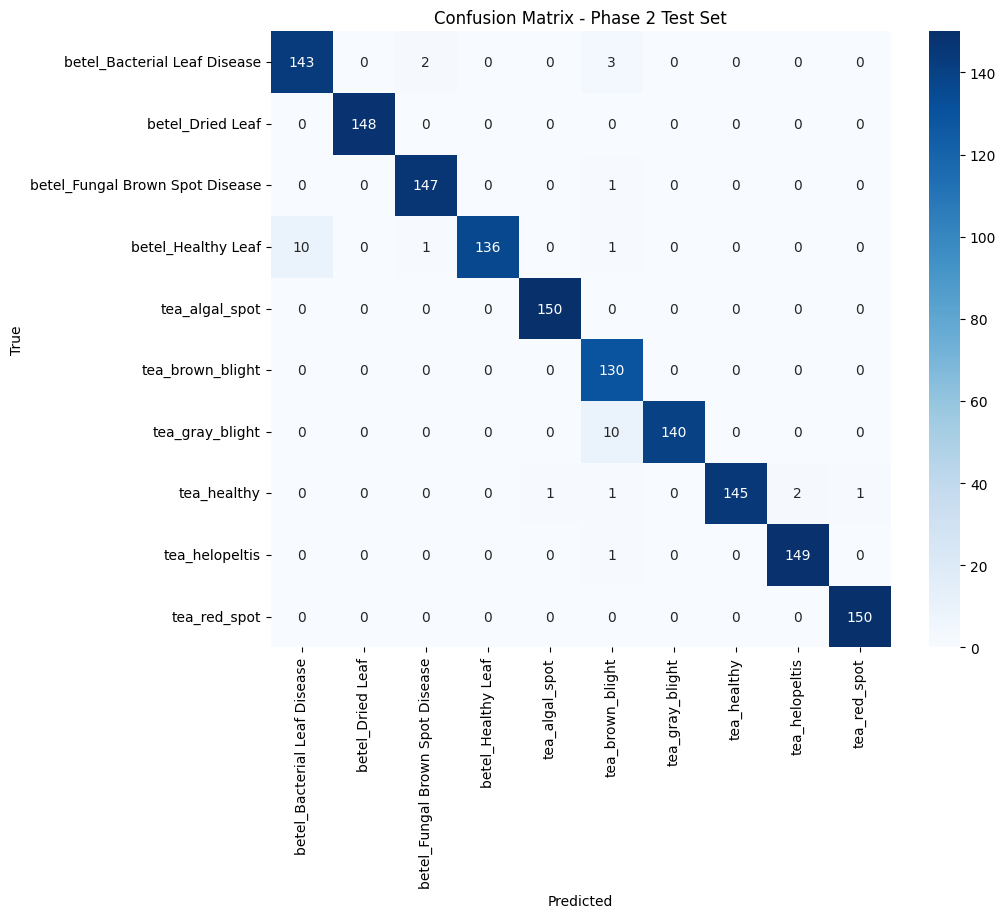

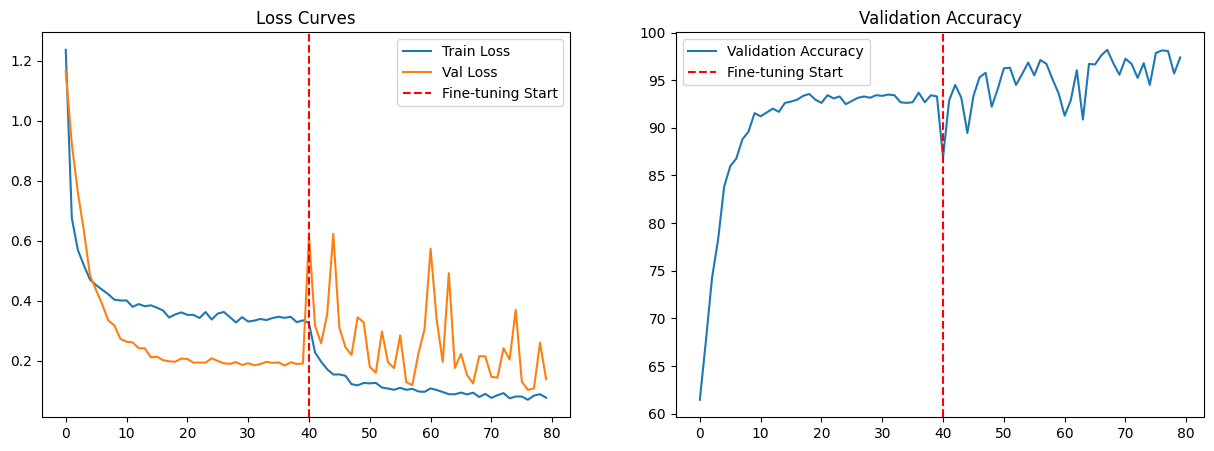

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchsummary import summary
from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

# Mount Google Drive
drive.mount('/content/drive')

# Configuration
data_dir = "/content/drive/MyDrive/final_data"
batch_size = 16
input_size = 224
num_classes = 10  # Update based on your dataset

# Data transforms
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(input_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(f'{data_dir}/train', train_transforms)
val_dataset = datasets.ImageFolder(f'{data_dir}/valid', val_test_transforms)
test_dataset = datasets.ImageFolder(f'{data_dir}/test', val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Initialize MnasNet model
model = models.mnasnet1_0(pretrained=True)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(model.classifier[1].in_features, num_classes)
)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

# Device config
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Model summary
def print_model_summary(model):
    summary(model, (3, input_size, input_size), device=str(device).split(':')[0])
    print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}\n")

print("\nInitial Model Summary (Frozen Backbone):")
print_model_summary(model)

# Loss and optimizer (no scheduler)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

# Evaluation function
def evaluate_model(model, dataloader, phase):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    acc = 100 * np.mean(np.array(y_true) == np.array(y_pred))
    print(f"\n✅ Test Accuracy ({phase}): {acc:.2f}%")

    print(f"\n📌 Classification Report ({phase}):")
    print(classification_report(y_true, y_pred, target_names=train_dataset.classes))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap='Blues')
    plt.title(f"Confusion Matrix - {phase}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Training variables
train_losses, val_losses, val_accuracies = [], [], []

# -------- Phase 1: Initial Training (40 Epochs) -------- #
print("\nPhase 1: Initial Training (Frozen Backbone)")
for epoch in range(40):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(100 * correct / total)

    print(f"Epoch {epoch+1}/40 | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accuracies[-1]:.2f}%")

# Evaluation after Phase 1
evaluate_model(model, test_loader, "Phase 1 Test Set")

# -------- Phase 2: Fine-tuning (Unfreeze last 20 layers) -------- #
print("\nUnfreezing last 20 layers of backbone")
layers = list(model.layers.children())
start_idx = max(0, len(layers) - 20)

for layer in layers[start_idx:]:
    for param in layer.parameters():
        param.requires_grad = True

# Updated optimizer (still no scheduler)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)

print("\nModel Summary After Unfreezing:")
print_model_summary(model)

# -------- Phase 2: Fine-tuning (40 Epochs) -------- #
print("\nPhase 2: Fine-tuning (40 Epochs)")
for epoch in range(40):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(100 * correct / total)

    print(f"Epoch {epoch+1}/40 | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accuracies[-1]:.2f}%")

# Final evaluation
evaluate_model(model, test_loader, "Phase 2 Test Set")

# -------- Plotting -------- #
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.axvline(40, color='r', linestyle='--', label='Fine-tuning Start')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.axvline(40, color='r', linestyle='--', label='Fine-tuning Start')
plt.title('Validation Accuracy')
plt.legend()
plt.show()


In [2]:
def plot_phase_curves(history, phase_name):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
    plt.title(f'{phase_name} - Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(epochs, history['val_acc'], label='Val Accuracy', marker='o')
    plt.title(f'{phase_name} - Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
